# Concurrency 128 Benchmark Comparison: Baseline vs. KV Offloading (HiCache)

Clean white-background charts for **Concurrency 128** with high-contrast, balanced bar colors (`#475569` Slate for Baseline vs `#ea580c` Vibrant Orange for HiCache), descriptive units, top-aligned titles, 2-item legend, and clear winner indicators.

In [4]:
%matplotlib inline
import os
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Robust Path Resolver for AIPerf JSON exports
def resolve_json_path(rel_subpath: str) -> Path:
    abs_base = Path("/data/inference/cluster/models/qwen3.6-35B-A3B/artifacts/tp1-ep2-4p4d")
    candidate = abs_base / rel_subpath
    if candidate.exists():
        return candidate
    cwd = Path(os.getcwd())
    for p in [cwd] + list(cwd.parents):
        cand = p / "artifacts/tp1-ep2-4p4d" / rel_subpath
        if cand.exists():
            return cand
    return candidate

BASELINE_JSON = resolve_json_path("baseline-kv-aware/isl-64536_osl-256/c128/profile_export_aiperf.json")
OFFLOAD_JSON = resolve_json_path("baseline-kv-aware+offloading/isl-64536_osl-256/c128/profile_export_aiperf.json")

# High-Contrast Professional Palette (White Theme)
BG_COLOR = "#ffffff"       # Pure white background
CARD_BG = "#ffffff"        # Pure white plot area
GRID_COLOR = "#e2e8f0"     # Subtle slate gridline
BORDER_COLOR = "#cbd5e1"   # Clean border
TEXT_MUTED = "#64748b"     # Muted slate for units/subheaders
TEXT_MAIN = "#1e293b"      # Dark slate for labels
TEXT_DARK = "#0f172a"      # Deep charcoal for titles and numbers
COLOR_BASELINE = "#475569" # Solid Slate Gray for Baseline (GPU VRAM / HBM)
COLOR_OFFLOAD = "#ea580c"  # Vibrant Orange for KV Offload (HiCache CPU)
WINNER_BG = "#ecfdf5"      # Light emerald green badge background
WINNER_BORDER = "#a7f3d0"  # Light emerald green border
WINNER_TEXT = "#047857"    # Dark emerald green text

# def load_metrics(json_path: Path) -> dict:
#     if not json_path.exists():
#         raise FileNotFoundError(f"Metrics file not found: {json_path}")
#     with open(json_path, "r", encoding="utf-8") as f:
#         data = json.load(f)
#     return {
#         "output_tokens_per_sec": data.get("output_token_throughput", {}).get("avg", 0.0),
#         "request_throughput": data.get("request_throughput", {}).get("avg", 0.0),
#         "total_token_throughput": data.get("total_token_throughput", {}).get("avg", 0.0),
#         "ttft_p50_ms": data.get("time_to_first_token", {}).get("p50", 0.0),
#         "ttft_p95_ms": data.get("time_to_first_token", {}).get("p95", 0.0),
#         "ttft_p50_s": data.get("time_to_first_token", {}).get("p50", 0.0) / 1000.0,
#         "ttft_p95_s": data.get("time_to_first_token", {}).get("p95", 0.0) / 1000.0,
#         "itl_p50_ms": data.get("inter_token_latency", {}).get("p50", 0.0),
#         "itl_p95_ms": data.get("inter_token_latency", {}).get("p95", 0.0),
#         "itl_p99_ms": data.get("inter_token_latency", {}).get("p99", 0.0),
#         "e2e_p50_ms": data.get("request_latency", {}).get("p50", 0.0),
#         "e2e_p95_ms": data.get("request_latency", {}).get("p95", 0.0),
#         "e2e_p50_s": data.get("request_latency", {}).get("p50", 0.0) / 1000.0,
#         "e2e_p95_s": data.get("request_latency", {}).get("p95", 0.0) / 1000.0,
#         "cache_hit_pct": data.get("overall_usage_prompt_cache_read_pct", {}).get("avg", 0.0),
#     }

def load_metrics(json_path: Path) -> dict:
    if not json_path.exists():
        raise FileNotFoundError(f"Metrics file not found: {json_path}")
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    return {
        "output_tokens_per_sec": data.get("output_token_throughput", {}).get("avg", 0.0),
        "request_throughput": data.get("request_throughput", {}).get("avg", 0.0),
        "total_token_throughput": data.get("total_token_throughput", {}).get("avg", 0.0),
        "ttft_p99_ms": data.get("time_to_first_token", {}).get("p99", 0.0),
        "ttft_p99_s": data.get("time_to_first_token", {}).get("p99", 0.0) / 1000.0,
        "tpot_p99_ms": data.get("time_to_second_token", {}).get("p99", data.get("inter_token_latency", {}).get("p99", 0.0)),
        "itl_p99_ms": data.get("inter_token_latency", {}).get("p99", 0.0),
        "e2e_p99_ms": data.get("request_latency", {}).get("p99", 0.0),
        "e2e_p99_s": data.get("request_latency", {}).get("p99", 0.0) / 1000.0,
        "cache_hit_pct": data.get("overall_usage_prompt_cache_read_pct", {}).get("avg", 0.0),
    }

base = load_metrics(BASELINE_JSON)
offload = load_metrics(OFFLOAD_JSON)

def draw_single_card(
    ax,
    title: str,
    val_baseline: float,
    val_offload: float,
    unit: str,
    y_axis_label: str = None,
    higher_is_better: bool = True,
    y_max: float = None,
    format_str: str = "{:.2f}",
    detail_unit: str = None,
    val_baseline_detail: float = None,
    val_offload_detail: float = None,
    show_x_labels: bool = False,
):
    ax.set_facecolor(CARD_BG)
    x_positions = [0.75, 1.75]
    bar_width = 0.44

    # Determine Winner & Plain Text Direction
    if higher_is_better:
        base_wins = val_baseline > val_offload
        offload_wins = val_offload > val_baseline
        direction_text = "Higher is better"
    else:
        base_wins = val_baseline < val_offload
        offload_wins = val_offload < val_baseline
        direction_text = "Lower is better"

    ax.bar(
        x_positions,
        [val_baseline, val_offload],
        width=bar_width,
        color=[COLOR_BASELINE, COLOR_OFFLOAD],
        edgecolor=[COLOR_BASELINE, COLOR_OFFLOAD],
        linewidth=1.0,
        zorder=3,
    )

    max_val = max(val_baseline, val_offload)
    if y_max is None:
        y_max = max_val * 1.35 if max_val > 0 else 1.0

    ax.set_ylim(0, y_max)
    ax.set_xlim(0.1, 2.4)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7, color=GRID_COLOR, zorder=1)
    ax.xaxis.grid(False)

    # Title Placed Cleanly Above the Plot Area
    title_full = f"{title.upper()}  ({direction_text})"
    ax.set_title(
        title_full,
        loc="left",
        fontsize=9.5,
        fontweight="bold",
        color=TEXT_DARK,
        pad=10,
    )

    # Clearly Formatted Vertical Y-Axis Label
    label_text = y_axis_label if y_axis_label else f"({unit})"
    ax.set_ylabel(label_text, color=TEXT_MUTED, fontsize=9.0, labelpad=6)
    ax.tick_params(axis="y", colors=TEXT_MUTED, labelsize=8.5, length=0)
    ax.tick_params(axis="x", length=0, pad=6)

    # X-Axis Configuration
    if show_x_labels:
        ax.set_xticks(x_positions)
        ax.set_xticklabels(
            ["Baseline", "KV Offloading"],
            color=TEXT_MAIN, fontsize=9.0, fontweight="medium"
        )
    else:
        ax.set_xticks([])

    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BORDER_COLOR)
    ax.spines["bottom"].set_linewidth(1.0)

    # Difference Calculation
    if higher_is_better:
        pct_diff = ((val_offload - val_baseline) / val_baseline) * 100 if val_baseline > 0 else 0
        diff_label = f"+{pct_diff:.1f}%"
    else:
        if val_baseline > 0:
            reduction = ((val_baseline - val_offload) / val_baseline) * 100
            diff_label = f"{abs(reduction):.1f}% faster" if val_offload < val_baseline else f"+{abs(reduction):.1f}% slower"
        else:
            diff_label = ""

    # Value strings with descriptive unit notation
    if val_baseline_detail is not None:
        base_text = f"{format_str.format(val_baseline)} {unit}\n({val_baseline_detail:,.0f} {detail_unit})"
    else:
        base_text = f"{format_str.format(val_baseline)} {unit}"

    if val_offload_detail is not None:
        offload_text = f"{format_str.format(val_offload)} {unit}\n({val_offload_detail:,.0f} {detail_unit})"
    else:
        offload_text = f"{format_str.format(val_offload)} {unit}"

    # Annotate Baseline Value
    ax.text(
        0.75, val_baseline + (y_max * 0.02), base_text,
        ha="center", va="bottom", color=TEXT_DARK if base_wins else TEXT_MUTED,
        fontsize=8.5, fontweight="bold" if base_wins else "normal", zorder=6
    )

    # Annotate Offload Value
    ax.text(
        1.75, val_offload + (y_max * 0.02), offload_text,
        ha="center", va="bottom", color=TEXT_DARK if offload_wins else TEXT_MUTED,
        fontsize=8.5, fontweight="bold" if offload_wins else "normal", zorder=6
    )

    # Highlight Winner Badge
    bbox_winner = dict(
        boxstyle="round,pad=0.4,rounding_size=0.3",
        facecolor=WINNER_BG, edgecolor=WINNER_BORDER, linewidth=1.0
    )
    if offload_wins:
        badge_y = val_offload + (y_max * 0.16 if val_offload_detail else y_max * 0.09)
        ax.text(
            1.75, badge_y, f"★ WINNER ({diff_label})",
            ha="center", va="bottom", color=WINNER_TEXT, fontsize=8.0,
            fontweight="bold", bbox=bbox_winner, zorder=7
        )
    elif base_wins:
        badge_y = val_baseline + (y_max * 0.16 if val_baseline_detail else y_max * 0.09)
        ax.text(
            0.75, badge_y, "★ WINNER",
            ha="center", va="bottom", color=WINNER_TEXT, fontsize=8.0,
            fontweight="bold", bbox=bbox_winner, zorder=7
        )

print("✓ Setup complete and C128 metrics loaded!")

✓ Setup complete and C128 metrics loaded!


### 1. Output Token Throughput (Standalone Card)

findfont: Failed to find font weight medium, now using 400.


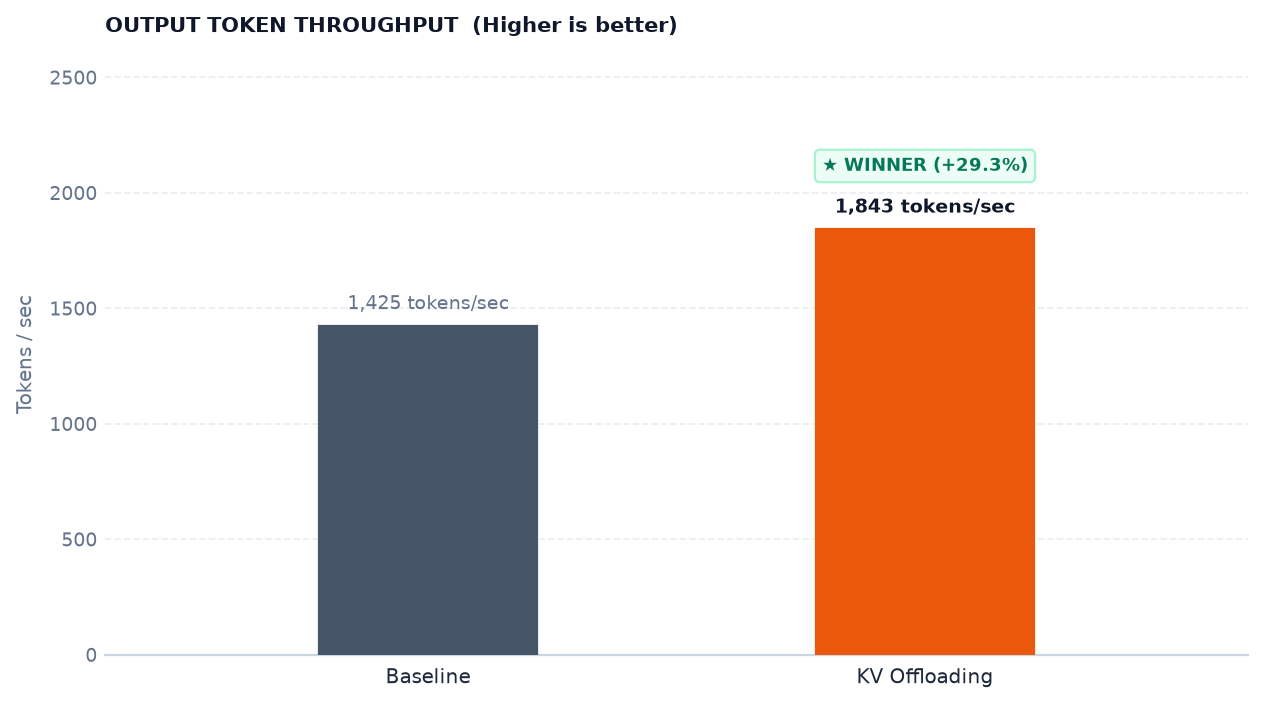

In [2]:
fig, ax = plt.subplots(figsize=(8.0, 4.5), facecolor=BG_COLOR, dpi=160)
draw_single_card(
    ax,
    title="Output Token Throughput",
    val_baseline=base["output_tokens_per_sec"],
    val_offload=offload["output_tokens_per_sec"],
    unit="tokens/sec",
    y_axis_label="Tokens / sec",
    higher_is_better=True,
    y_max=2600,
    format_str="{:,.0f}",
    show_x_labels=True,
)
plt.tight_layout()
plt.show()

### 2. Time to First Token (TTFT in seconds & milliseconds) — Lower is Better

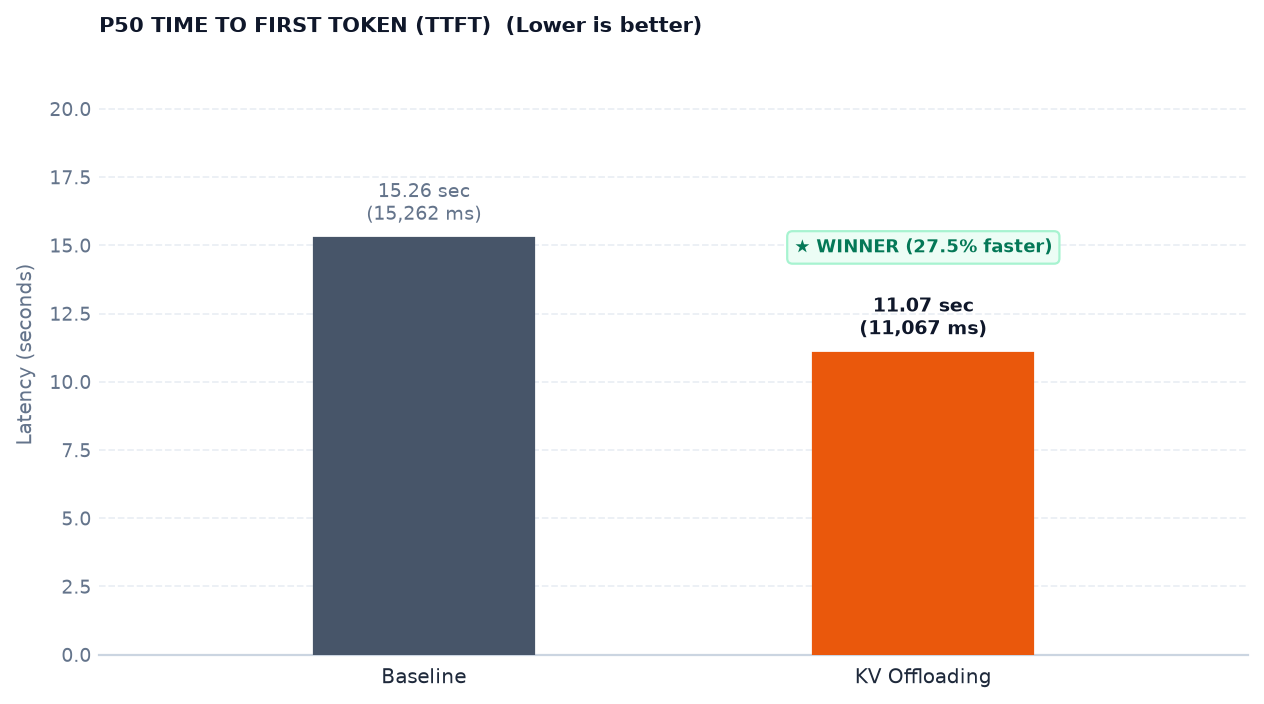

In [3]:
fig, ax = plt.subplots(figsize=(8.0, 4.5), facecolor=BG_COLOR, dpi=160)
draw_single_card(
    ax,
    title="P50 Time to First Token (TTFT)",
    val_baseline=base["ttft_p50_s"],
    val_offload=offload["ttft_p50_s"],
    unit="sec",
    y_axis_label="Latency (seconds)",
    higher_is_better=False,
    y_max=22.0,
    format_str="{:.2f}",
    detail_unit="ms",
    val_baseline_detail=base["ttft_p50_ms"],
    val_offload_detail=offload["ttft_p50_ms"],
    show_x_labels=True,
)
plt.tight_layout()
plt.show()

### 3. Complete 6-Panel Benchmark Dashboard (C128) with Descriptive Units & Legend

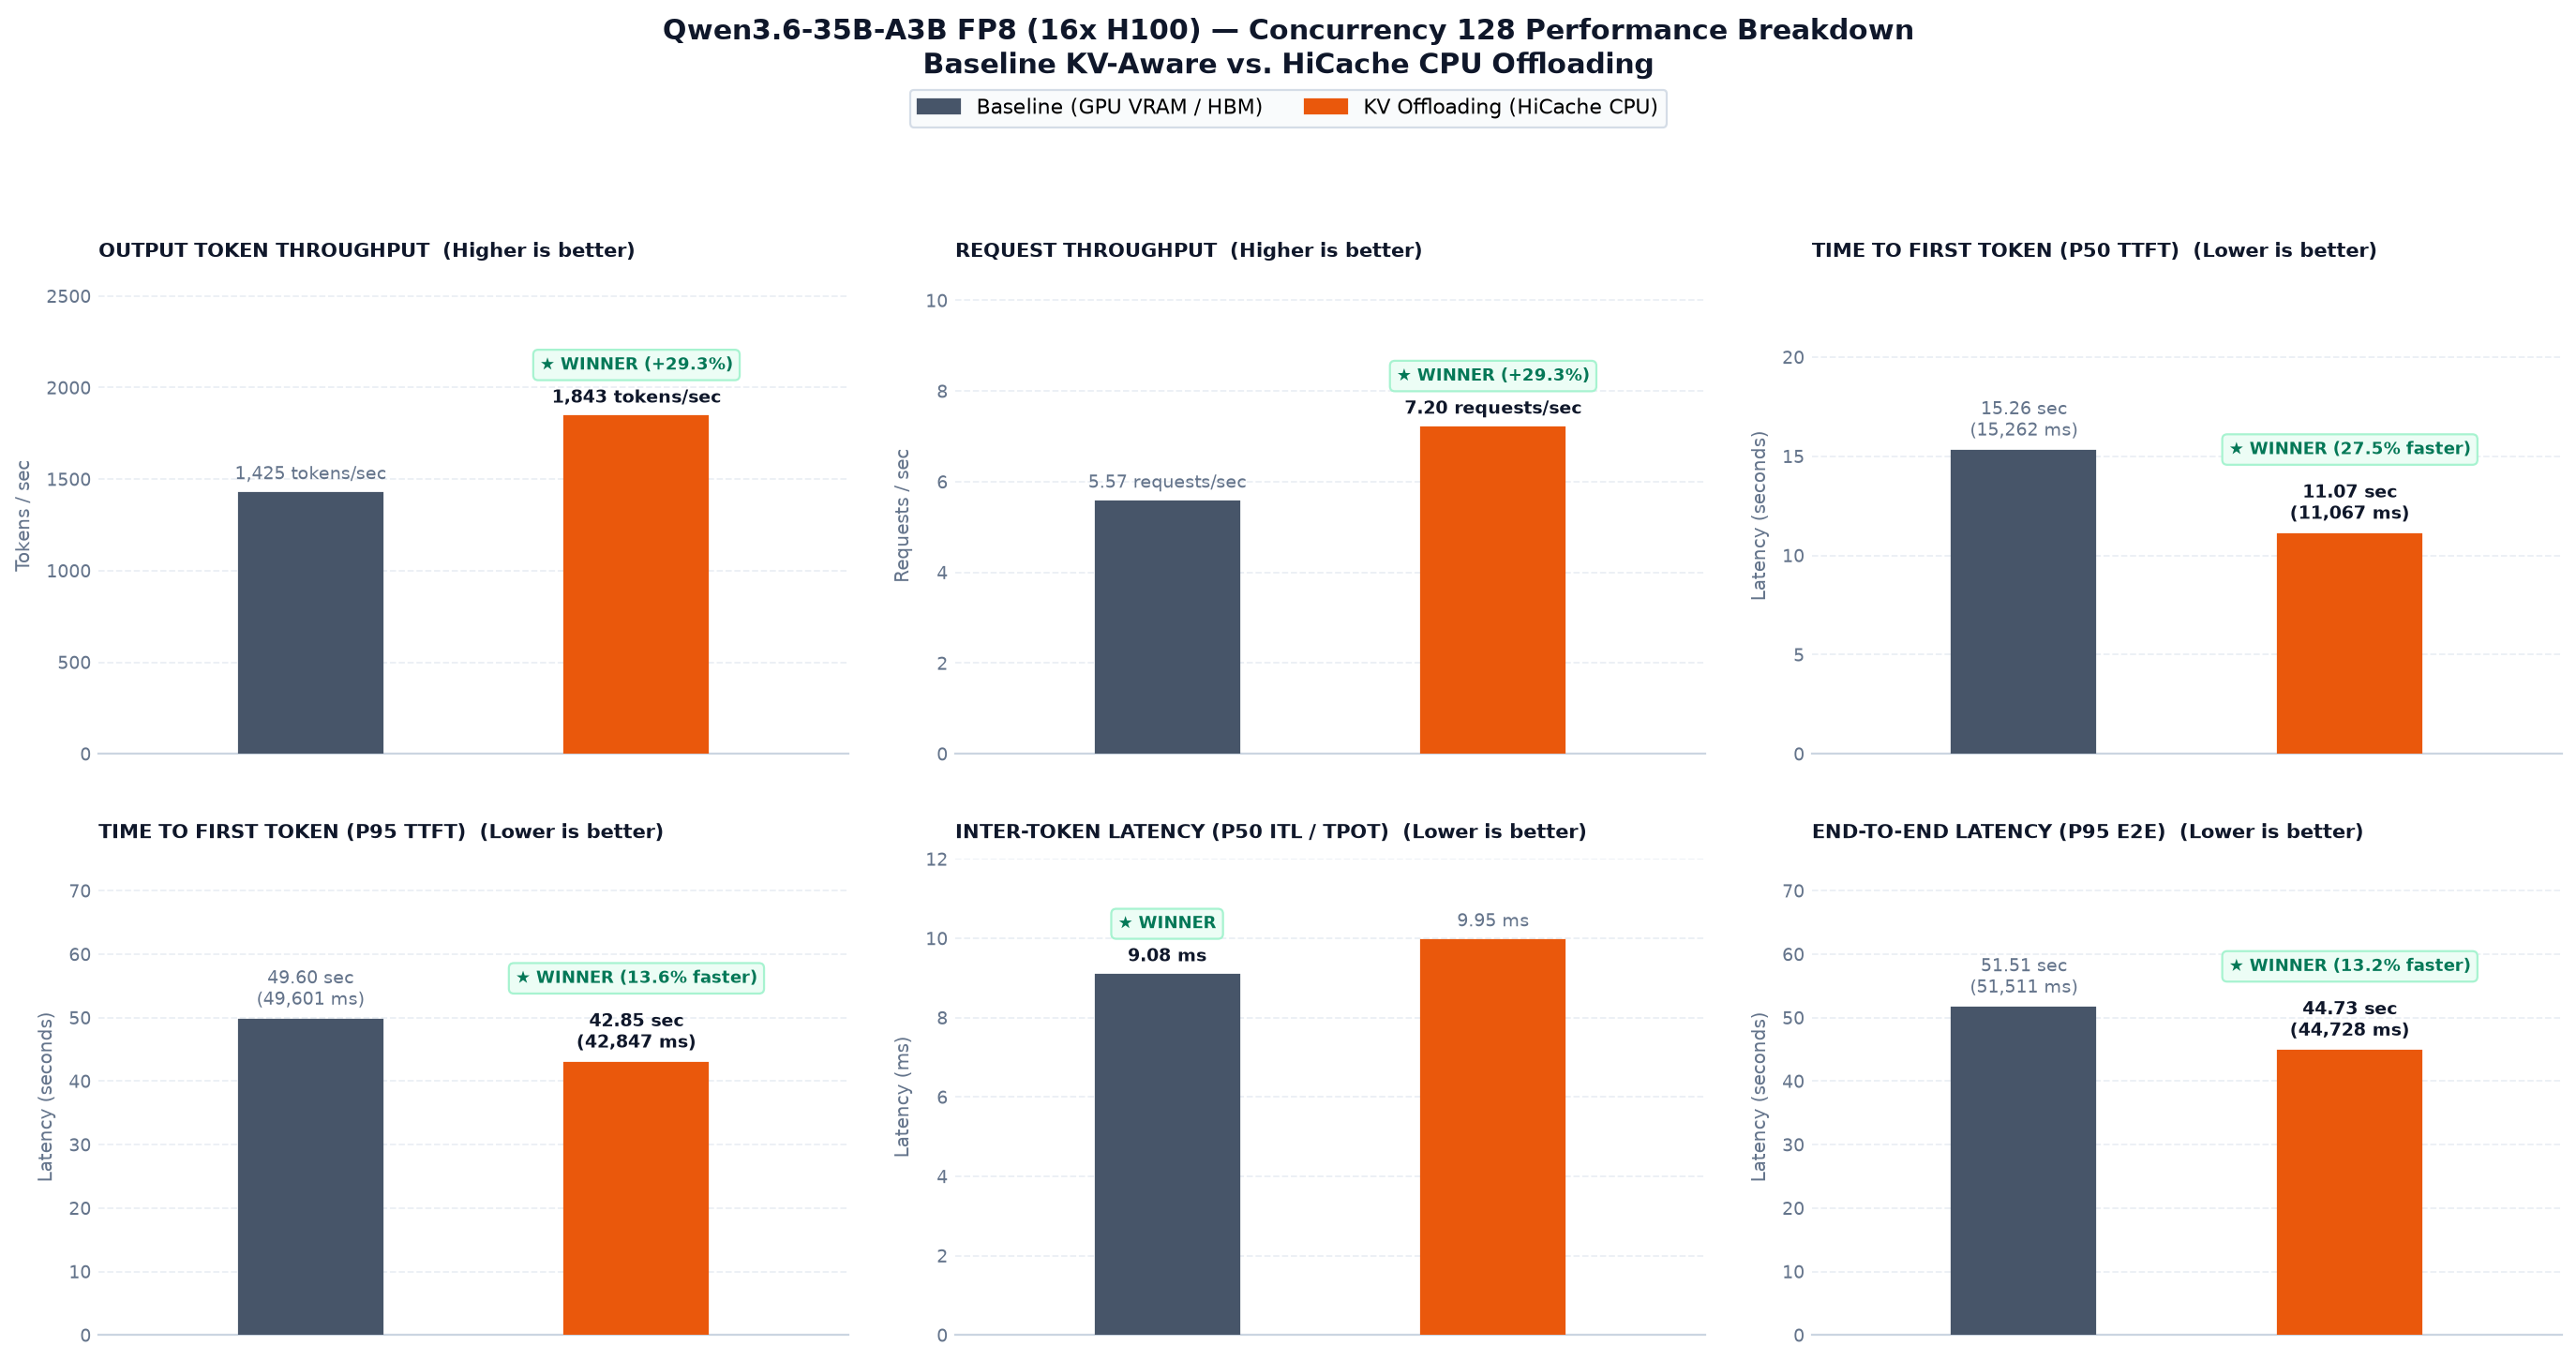

In [ ]:
metrics_list = [
    {
        "title": "Output Token Throughput",
        "base": base["output_tokens_per_sec"],
        "off": offload["output_tokens_per_sec"],
        "unit": "tokens/sec",
        "y_label": "Tokens / sec",
        "higher_is_better": True,
        "ymax": 2600,
        "fmt": "{:,.0f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Request Throughput",
        "base": base["request_throughput"],
        "off": offload["request_throughput"],
        "unit": "requests/sec",
        "y_label": "Requests / sec",
        "higher_is_better": True,
        "ymax": 10.5,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Time to First Token (P50 TTFT)",
        "base": base["ttft_p50_s"],
        "off": offload["ttft_p50_s"],
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 24.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base["ttft_p50_ms"],
        "off_det": offload["ttft_p50_ms"],
    },
    {
        "title": "Time to First Token (P95 TTFT)",
        "base": base["ttft_p95_s"],
        "off": offload["ttft_p95_s"],
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 75.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base["ttft_p95_ms"],
        "off_det": offload["ttft_p95_ms"],
    },
    {
        "title": "Inter-Token Latency (P50 ITL / TPOT)",
        "base": base["itl_p99_ms"],
        "off": offload["itl_p99_ms"],
        "unit": "ms",
        "y_label": "Latency (ms)",
        "higher_is_better": False,
        "ymax": 12.0,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "End-to-End Latency (P95 E2E)",
        "base": base["e2e_p95_s"],
        "off": offload["e2e_p95_s"],
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 75.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base["e2e_p95_ms"],
        "off_det": offload["e2e_p95_ms"],
    },
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9.5), facecolor=BG_COLOR, dpi=160)
fig.suptitle(
    "Qwen3.6-35B-A3B FP8 (16x H100) — Concurrency 128 Performance Breakdown\nBaseline KV-Aware vs. HiCache CPU Offloading",
    color=TEXT_DARK,
    fontsize=13.5,
    fontweight="bold",
    y=0.98,
)

# 2-Item Legend Only
patch_base = mpatches.Patch(color=COLOR_BASELINE, label="Baseline (GPU VRAM / HBM)")
patch_offload = mpatches.Patch(color=COLOR_OFFLOAD, label="KV Offloading (HiCache CPU RAM)")

fig.legend(
    handles=[patch_base, patch_offload],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=10.0,
)

for ax, m in zip(axes.flatten(), metrics_list):
    draw_single_card(
        ax=ax,
        title=m["title"],
        val_baseline=m["base"],
        val_offload=m["off"],
        unit=m["unit"],
        y_axis_label=m["y_label"],
        higher_is_better=m["higher_is_better"],
        y_max=m["ymax"],
        format_str=m["fmt"],
        detail_unit=m["det_unit"],
        val_baseline_detail=m["base_det"],
        val_offload_detail=m["off_det"],
        show_x_labels=False,
    )

plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.90], h_pad=2.8, w_pad=2.2)
plt.show()

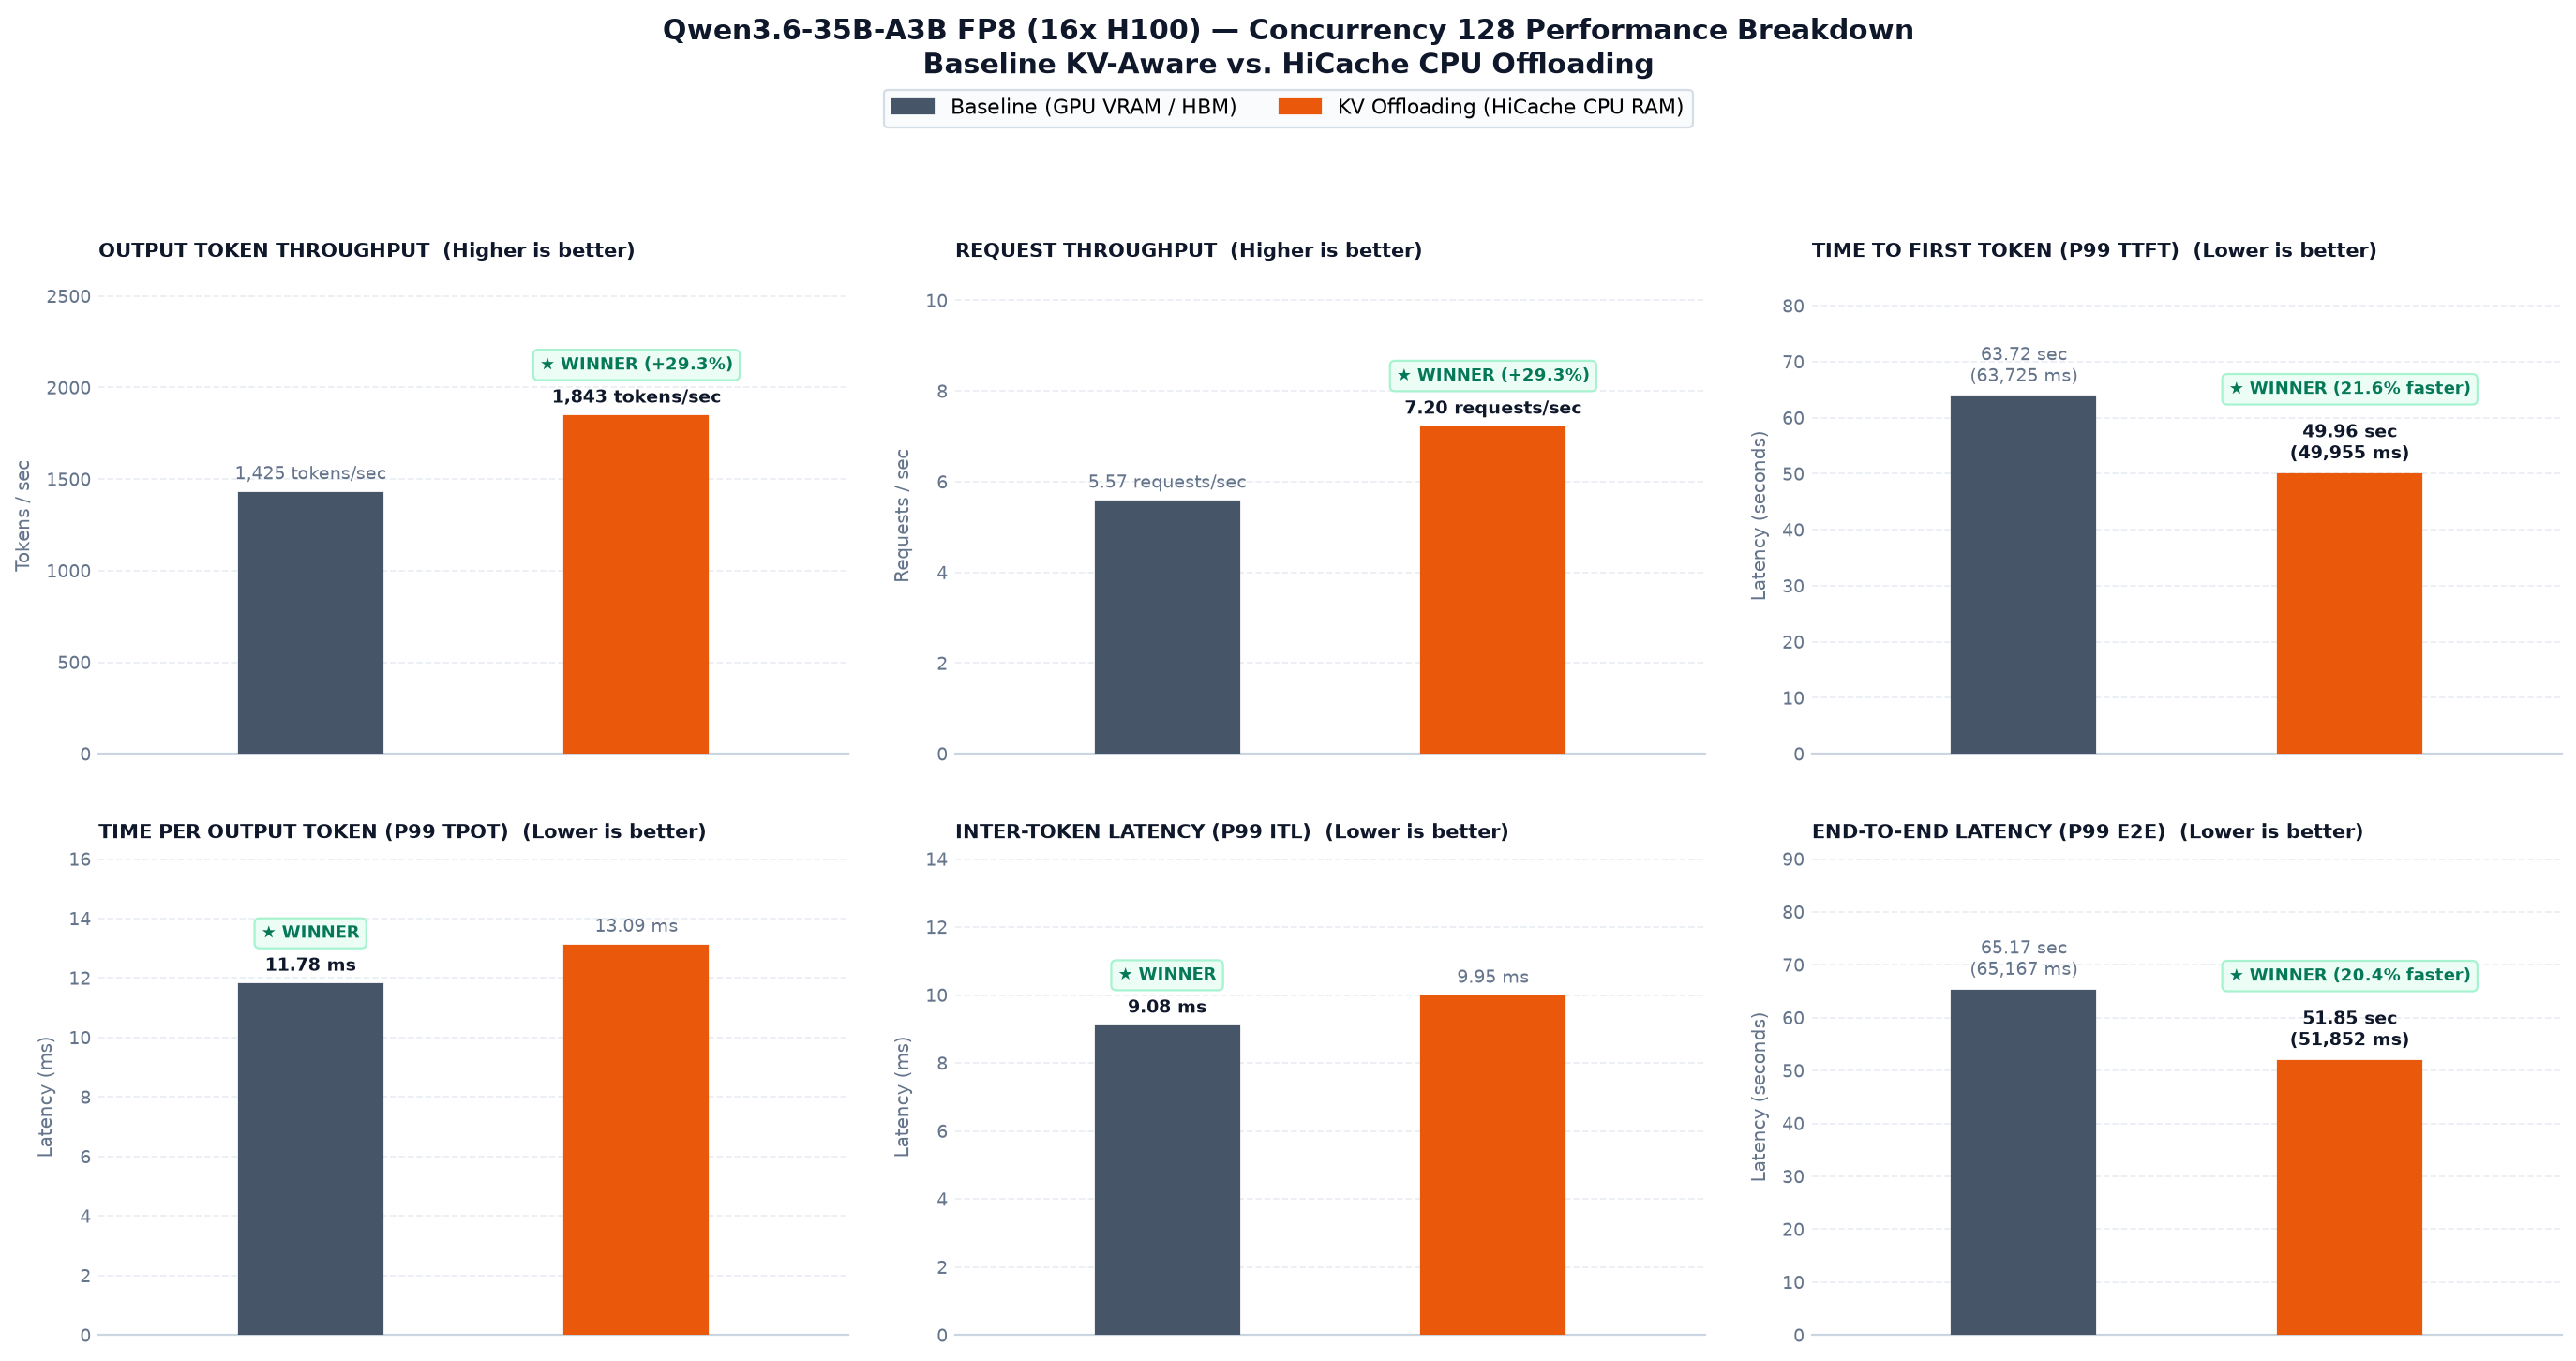

In [5]:
metrics_list = [
    {
        "title": "Output Token Throughput",
        "base": base["output_tokens_per_sec"],
        "off": offload["output_tokens_per_sec"],
        "unit": "tokens/sec",
        "y_label": "Tokens / sec",
        "higher_is_better": True,
        "ymax": 2600,
        "fmt": "{:,.0f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Request Throughput",
        "base": base["request_throughput"],
        "off": offload["request_throughput"],
        "unit": "requests/sec",
        "y_label": "Requests / sec",
        "higher_is_better": True,
        "ymax": 10.5,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Time to First Token (P99 TTFT)",
        "base": base.get("ttft_p99_s", base.get("ttft_p99_ms", 0.0) / 1000.0),
        "off": offload.get("ttft_p99_s", offload.get("ttft_p99_ms", 0.0) / 1000.0),
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 85.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base.get("ttft_p99_ms"),
        "off_det": offload.get("ttft_p99_ms"),
    },
    {
        "title": "Time Per Output Token (P99 TPOT)",
        "base": base.get("tpot_p99_ms", base.get("itl_p99_ms")),
        "off": offload.get("tpot_p99_ms", offload.get("itl_p99_ms")),
        "unit": "ms",
        "y_label": "Latency (ms)",
        "higher_is_better": False,
        "ymax": 16.0,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "Inter-Token Latency (P99 ITL)",
        "base": base["itl_p99_ms"],
        "off": offload["itl_p99_ms"],
        "unit": "ms",
        "y_label": "Latency (ms)",
        "higher_is_better": False,
        "ymax": 14.0,
        "fmt": "{:.2f}",
        "det_unit": None,
        "base_det": None,
        "off_det": None,
    },
    {
        "title": "End-to-End Latency (P99 E2E)",
        "base": base.get("e2e_p99_s", base.get("e2e_p99_ms", 0.0) / 1000.0),
        "off": offload.get("e2e_p99_s", offload.get("e2e_p99_ms", 0.0) / 1000.0),
        "unit": "sec",
        "y_label": "Latency (seconds)",
        "higher_is_better": False,
        "ymax": 90.0,
        "fmt": "{:.2f}",
        "det_unit": "ms",
        "base_det": base.get("e2e_p99_ms"),
        "off_det": offload.get("e2e_p99_ms"),
    },
]
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5), facecolor=BG_COLOR, dpi=160)
fig.suptitle(
    "Qwen3.6-35B-A3B FP8 (16x H100) — Concurrency 128 Performance Breakdown\nBaseline KV-Aware vs. HiCache CPU Offloading",
    color=TEXT_DARK,
    fontsize=13.5,
    fontweight="bold",
    y=0.98,
)
# 2-Item Legend Only
patch_base = mpatches.Patch(color=COLOR_BASELINE, label="Baseline (GPU VRAM / HBM)")
patch_offload = mpatches.Patch(color=COLOR_OFFLOAD, label="KV Offloading (HiCache CPU RAM)")
fig.legend(
    handles=[patch_base, patch_offload],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.935),
    ncol=2,
    frameon=True,
    facecolor="#f8fafc",
    edgecolor="#cbd5e1",
    fontsize=10.0,
)
for ax, m in zip(axes.flatten(), metrics_list):
    draw_single_card(
        ax=ax,
        title=m["title"],
        val_baseline=m["base"],
        val_offload=m["off"],
        unit=m["unit"],
        y_axis_label=m["y_label"],
        higher_is_better=m["higher_is_better"],
        y_max=m["ymax"],
        format_str=m["fmt"],
        detail_unit=m["det_unit"],
        val_baseline_detail=m["base_det"],
        val_offload_detail=m["off_det"],
        show_x_labels=False,
    )
plt.tight_layout(rect=[0.02, 0.03, 0.98, 0.90], h_pad=2.8, w_pad=2.2)
plt.show()